<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Solutions - Building a Variational Quantum Model

_Prepared by Claudia Zendejas-Morales_

This notebook contains complete solutions for the embedded tasks in notebook `2.5`.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, SparsePauliOp, state_fidelity

import pennylane as qml


<a id="task1-solution"></a>

## Task 1 (coding): One complete solution

We rebuild the same two-qubit forward model in Qiskit and compare the predicted labels under two thresholds.


sample            score      label@0.0    label@0.25
[0.1  0.45]     0.797       +1          +1
[0.55 0.95]     0.464       +1          +1
[1.  0.2]     0.352       +1          +1
[1.3 1. ]    -0.237       -1          -1

Samples whose label changes when the threshold increases to 0.25:


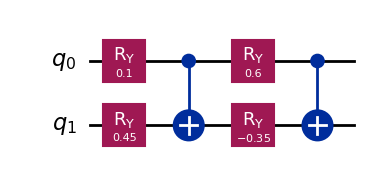

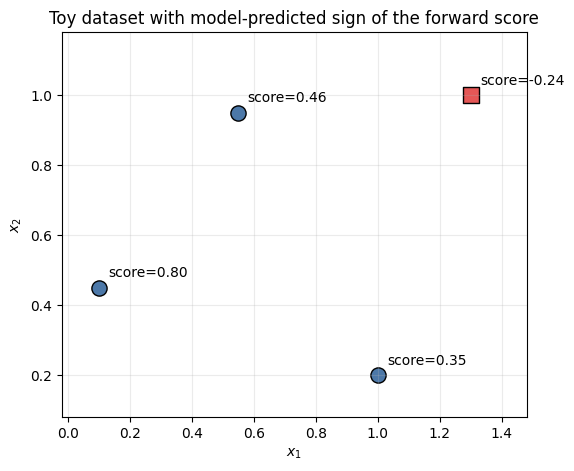

In [2]:
samples_task = np.array([
    [0.10, 0.45],
    [0.55, 0.95],
    [1.00, 0.20],
    [1.30, 1.00],
])
weights = np.array([0.60, -0.35])
thresholds = [0.0, 0.25]

Z0_OP = SparsePauliOp.from_list([("IZ", 1.0)])

def qiskit_forward_circuit(sample, weights):
    qc = QuantumCircuit(2)
    qc.ry(sample[0], 0)
    qc.ry(sample[1], 1)
    qc.cx(0, 1)
    qc.ry(weights[0], 0)
    qc.ry(weights[1], 1)
    qc.cx(0, 1)
    return qc

def qiskit_forward_score(sample, weights):
    sv = Statevector.from_instruction(qiskit_forward_circuit(sample, weights))
    return float(np.real(sv.expectation_value(Z0_OP)))

def predict_label_from_score(score, threshold=0.0):
    return +1 if score >= threshold else -1

scores = [qiskit_forward_score(sample, weights) for sample in samples_task]
print('sample            score      label@0.0    label@0.25')
changed = []
for sample, score in zip(samples_task, scores):
    label_0 = predict_label_from_score(score, threshold=0.0)
    label_025 = predict_label_from_score(score, threshold=0.25)
    if label_0 != label_025:
        changed.append(sample)
    print(f"{sample}   {score:7.3f}       {label_0:+d}          {label_025:+d}")

print('\nSamples whose label changes when the threshold increases to 0.25:')
for sample in changed:
    print(sample)

display(qiskit_forward_circuit(samples_task[0], weights).draw('mpl'))

plt.figure(figsize=(6, 5))
colors = ["#4c78a8" if predict_label_from_score(qiskit_forward_score(sample, weights), threshold=0.0) > 0 else "#e45756" for sample in samples_task]
for sample, color in zip(samples_task, colors):
    marker = "o" if predict_label_from_score(qiskit_forward_score(sample, weights), threshold=0.0) > 0 else "s"
    plt.scatter(sample[0], sample[1], s=120, c=color, marker=marker, edgecolor="black")
    plt.text(sample[0] + 0.03, sample[1] + 0.03, f"score={qiskit_forward_score(sample, weights):.2f}", fontsize=10)
plt.xlim(samples_task[:, 0].min() - 0.12, samples_task[:, 0].max() + 0.18)
plt.ylim(samples_task[:, 1].min() - 0.12, samples_task[:, 1].max() + 0.18)
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Toy dataset with model-predicted sign of the forward score")
plt.grid(alpha=0.25)
plt.show()


Changing the threshold does not change the quantum model itself. It only changes the final classical decision rule applied to the same scalar score. This is another way to see that the forward circuit and the label map are related but distinct design choices.


<a id="task2-solution"></a>

## Task 2 (coding): One complete solution

We use the same Qiskit state-preparation model to compute classification, regression, and similarity outputs on the same sample set.


sample            cls score   cls label   regression
[0.18 0.22]     0.869      +1          1.456
[0.6 0.7]     0.585      +1          1.143
[1.05 0.3 ]     0.337      +1          0.870
[1.35 0.95]    -0.148      -1          0.337


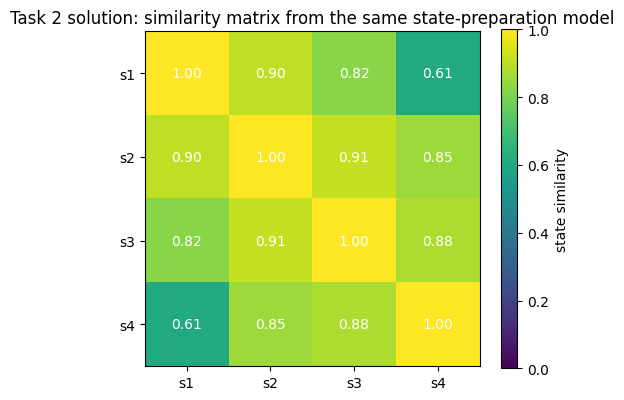

Most similar distinct pair: s2 and s3 with similarity 0.913
Their classification scores are 0.585 and 0.337, and their regression outputs are 1.143 and 0.870.
This pair does receive relatively similar scalar outputs here, but that need not be true in general: state similarity and scalar readout similarity are related through the chosen observable and post-processing map, not by identity.


In [3]:
samples_task = np.array([
    np.array([0.18, 0.22]),
    np.array([0.60, 0.70]),
    np.array([1.05, 0.30]),
    np.array([1.35, 0.95]),
])
weights = np.array([0.45, -0.20])
Z0_OP = SparsePauliOp.from_list([("IZ", 1.0)])

def qiskit_state_prep_circuit(sample, weights):
    qc = QuantumCircuit(2)
    qc.ry(sample[0], 0)
    qc.ry(sample[1], 1)
    qc.cx(0, 1)
    qc.ry(weights[0], 0)
    qc.ry(weights[1], 1)
    qc.cx(0, 1)
    return qc

def prepared_state_task(sample, weights):
    return Statevector.from_instruction(qiskit_state_prep_circuit(sample, weights))

def classification_score_task(sample, weights):
    sv = prepared_state_task(sample, weights)
    return float(np.real(sv.expectation_value(Z0_OP)))

def regression_output_task(sample, weights):
    return 0.5 + 1.1 * classification_score_task(sample, weights)

print('sample            cls score   cls label   regression')
cls_scores = []
for sample in samples_task:
    score = classification_score_task(sample, weights)
    cls_scores.append(score)
    label = +1 if score >= 0 else -1
    reg = regression_output_task(sample, weights)
    print(f"{sample}   {score:7.3f}      {label:+d}        {reg:7.3f}")

sim_matrix = np.zeros((len(samples_task), len(samples_task)))
for a in range(len(samples_task)):
    for b in range(len(samples_task)):
        sim_matrix[a, b] = float(
            state_fidelity(
                prepared_state_task(samples_task[a], weights),
                prepared_state_task(samples_task[b], weights),
            )
        )

plt.figure(figsize=(5.4, 4.4))
plt.imshow(sim_matrix, vmin=0.0, vmax=1.0, cmap='viridis')
plt.xticks(range(len(samples_task)), [f"s{i+1}" for i in range(len(samples_task))])
plt.yticks(range(len(samples_task)), [f"s{i+1}" for i in range(len(samples_task))])
plt.colorbar(label='state similarity')
plt.title('Task 2 solution: similarity matrix from the same state-preparation model')
for i in range(sim_matrix.shape[0]):
    for j in range(sim_matrix.shape[1]):
        plt.text(j, i, f"{sim_matrix[i, j]:.2f}", ha='center', va='center', color='white')
plt.show()

masked = sim_matrix.copy()
np.fill_diagonal(masked, -1.0)
i_best, j_best = np.unravel_index(np.argmax(masked), masked.shape)
print(f"Most similar distinct pair: s{i_best+1} and s{j_best+1} with similarity {sim_matrix[i_best, j_best]:.3f}")
print(f"Their classification scores are {cls_scores[i_best]:.3f} and {cls_scores[j_best]:.3f}, and their regression outputs are {regression_output_task(samples_task[i_best], weights):.3f} and {regression_output_task(samples_task[j_best], weights):.3f}.")
print("This pair does receive relatively similar scalar outputs here, but that need not be true in general: state similarity and scalar readout similarity are related through the chosen observable and post-processing map, not by identity.")


The most similar pair under state fidelity need not be the pair with the closest regression outputs or the same thresholded label. Similarity and scalar prediction are different ways of reading the same state-preparation block.


<a id="task3-solution"></a>

## Task 3 (design): One complete solution

These are sample specifications, not unique correct answers. The main criterion is internal coherence between encoding, ansatz, and readout.


**Scenario A**. A reasonable choice is angle encoding on two qubits, a shallow two-local ansatz, and a binary readout based on the sign of $\langle Z_0 \rangle$. The feature dimension is only two, so angle encoding is simple and natural. A shallow two-local circuit is enough because the qubit budget is very small and the task is binary classification rather than rich generative modeling. The readout is easy to interpret because the sign of one expectation value maps directly into a binary decision. This design also keeps the measurement cost low, which matters if later one wants to move from simulation to shot-based execution.

**Scenario B**. A reasonable choice is angle encoding on four qubits or a two-features-per-qubit strategy on two qubits, combined with a modest ansatz and a scalar regression readout such as $a + b\langle Z_0 \rangle$. Since the target is a bounded real number, the affine map on top of a bounded expectation value gives a prediction with clear scale semantics. The ansatz does not need to be deep at this stage because interpretability before training is part of the goal. A single-observable regression head is also cheaper to estimate than a richer multi-basis head. If shot noise later becomes relevant, the scalar readout remains comparatively simple to estimate.

**Scenario C**. A reasonable choice is an encoding and ansatz chosen mainly for state-preparation quality, together with a similarity output based on state fidelity rather than an immediate class label. In this setting the goal is not yet to force the model into a classifier or regressor. What matters first is whether the circuit maps similar classical samples to similar quantum states and separates dissimilar ones. A shallow but expressive state-preparation block is enough for this exploratory stage. This is coherent with later kernel-based methods, where similarity itself becomes the central object of interest.
